# 06 — Explainability, Error Analysis and Bias Audit

Three questions:

1. **Why** does the model decide what it decides — globally and for one flow?
2. **What** does it get wrong, and is the error concentrated anywhere?
3. **Is the audit fair** — and what can this dataset actually support?

> Explaining a model is not fitting it. These analyses run on the test split
> legitimately, because the model and threshold were frozen before it was opened
> and nothing here feeds back into either.

```bash
python -m src.pipeline --evaluate
```

In [1]:
import sys, warnings
from pathlib import Path

# Make the repository root importable no matter where Jupyter was launched from.
ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

from src import config
print(f"Repository root : {ROOT}")
print(f"Random seed     : {config.RANDOM_STATE}")

Repository root : E:\AIM\AIM AI ML Capstone\AI_Capstone_Network_Intrusion_Detection
Random seed     : 42


In [2]:
def show(figure_name, caption=None):
    """Display a figure produced by the pipeline, or explain how to produce it."""
    path = config.FIGURES_DIR / f"{figure_name}.png"
    if path.exists():
        display(Image(filename=str(path)))
        if caption:
            display(Markdown(f"*{caption}*"))
    else:
        display(Markdown(
            f"> ⚠️ `figures/{figure_name}.png` not found. "
            "Run the pipeline stage noted above to generate it."))

In [3]:
import json

deployment_path = config.MODELS_DIR / "deployment.json"
deployment = (json.loads(deployment_path.read_text(encoding="utf-8"))
              if deployment_path.exists() else {})
if deployment:
    print(f"Explaining : {deployment['display_name']}")
    print(f"Threshold  : {deployment['threshold']:.3f}")

Explaining : LightGBM
Threshold  : 0.465


## 1. Global SHAP importance

SHAP is used in preference to impurity-based importance, which is biased toward
high-cardinality features and splits credit arbitrarily between the correlated
feature twins identified in notebook 02.

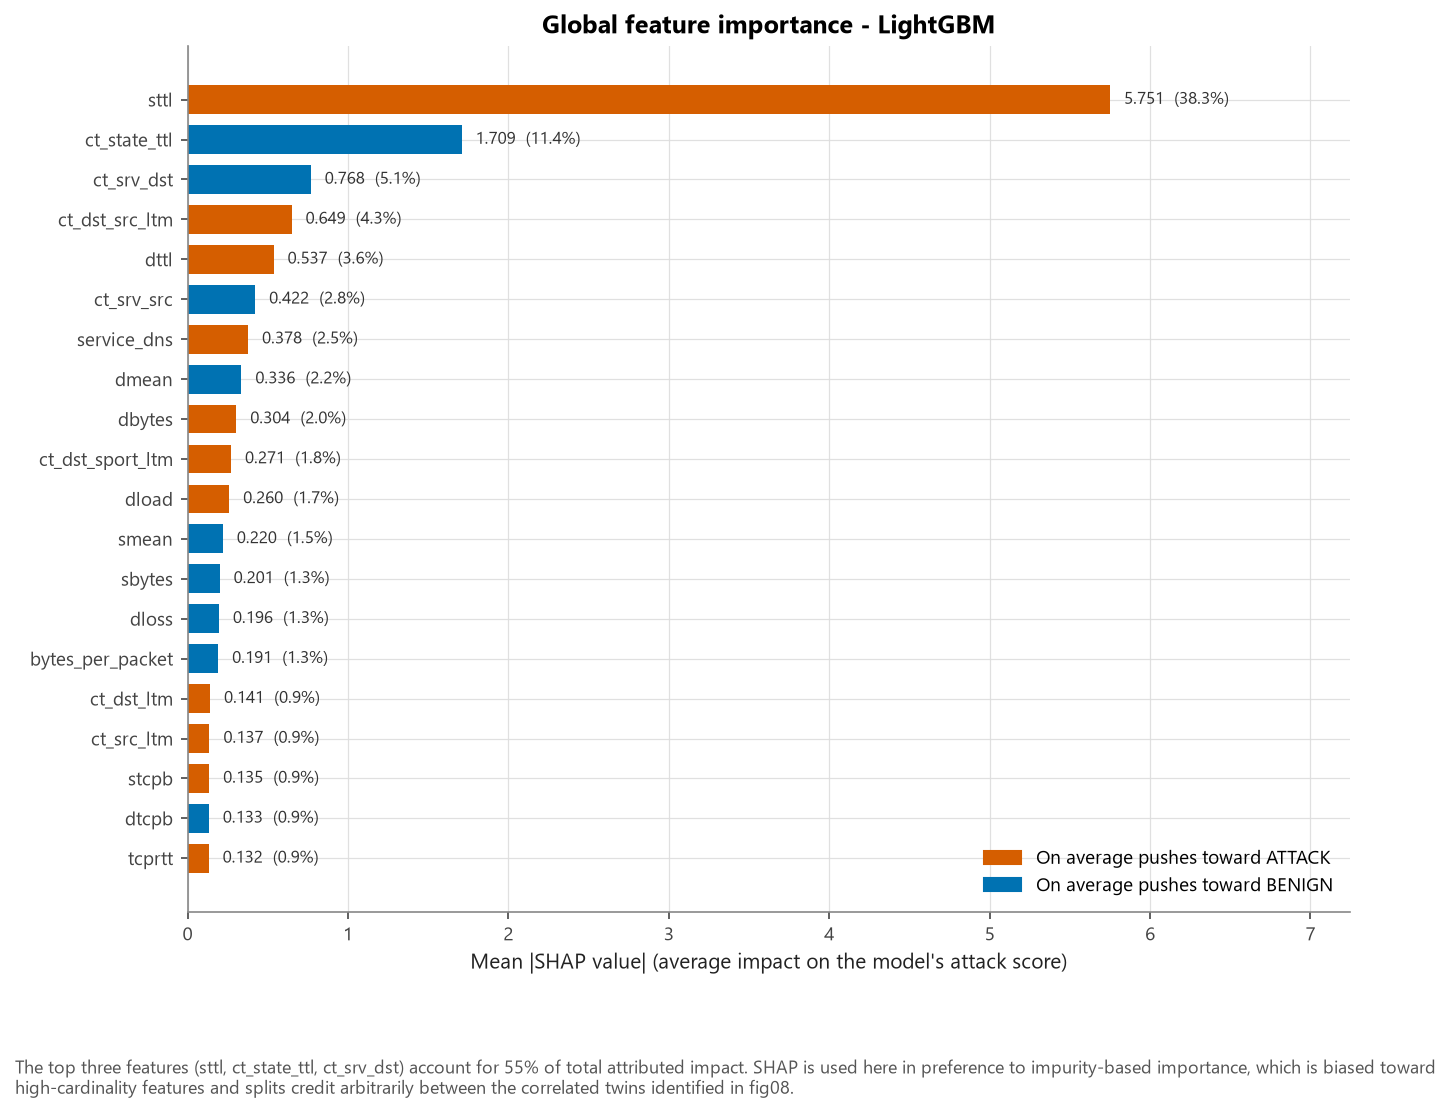

In [4]:
show("fig20_shap_global_importance")

In [5]:
shap_path = config.METRICS_DIR / "shap_analysis.json"
shap_payload = json.loads(shap_path.read_text(encoding="utf-8")) if shap_path.exists() else None

if shap_payload:
    importance = pd.DataFrame(shap_payload["global_importance"]).head(15)
    importance["direction"] = np.where(importance["mean_shap"] > 0,
                                       "toward ATTACK", "toward BENIGN")
    display(importance[["feature", "mean_abs_shap", "share_of_total", "direction"]]
            .style.format({"mean_abs_shap": "{:.4f}", "share_of_total": "{:.1%}"}))
else:
    display(Markdown("> Run `python -m src.pipeline --evaluate` first."))

,feature,mean_abs_shap,share_of_total,direction
0,sttl,5.7510,38.3%,toward ATTACK
1,ct_state_ttl,1.7088,11.4%,toward BENIGN
2,ct_srv_dst,0.7684,5.1%,toward BENIGN
3,ct_dst_src_ltm,0.6490,4.3%,toward ATTACK
4,dttl,0.5367,3.6%,toward ATTACK
5,ct_srv_src,0.4217,2.8%,toward BENIGN
6,service_dns,0.3776,2.5%,toward ATTACK
7,dmean,0.3359,2.2%,toward BENIGN
8,dbytes,0.3042,2.0%,toward ATTACK
9,ct_dst_sport_ltm,0.2712,1.8%,toward ATTACK


## 2. Beeswarm — distribution and direction of every effect

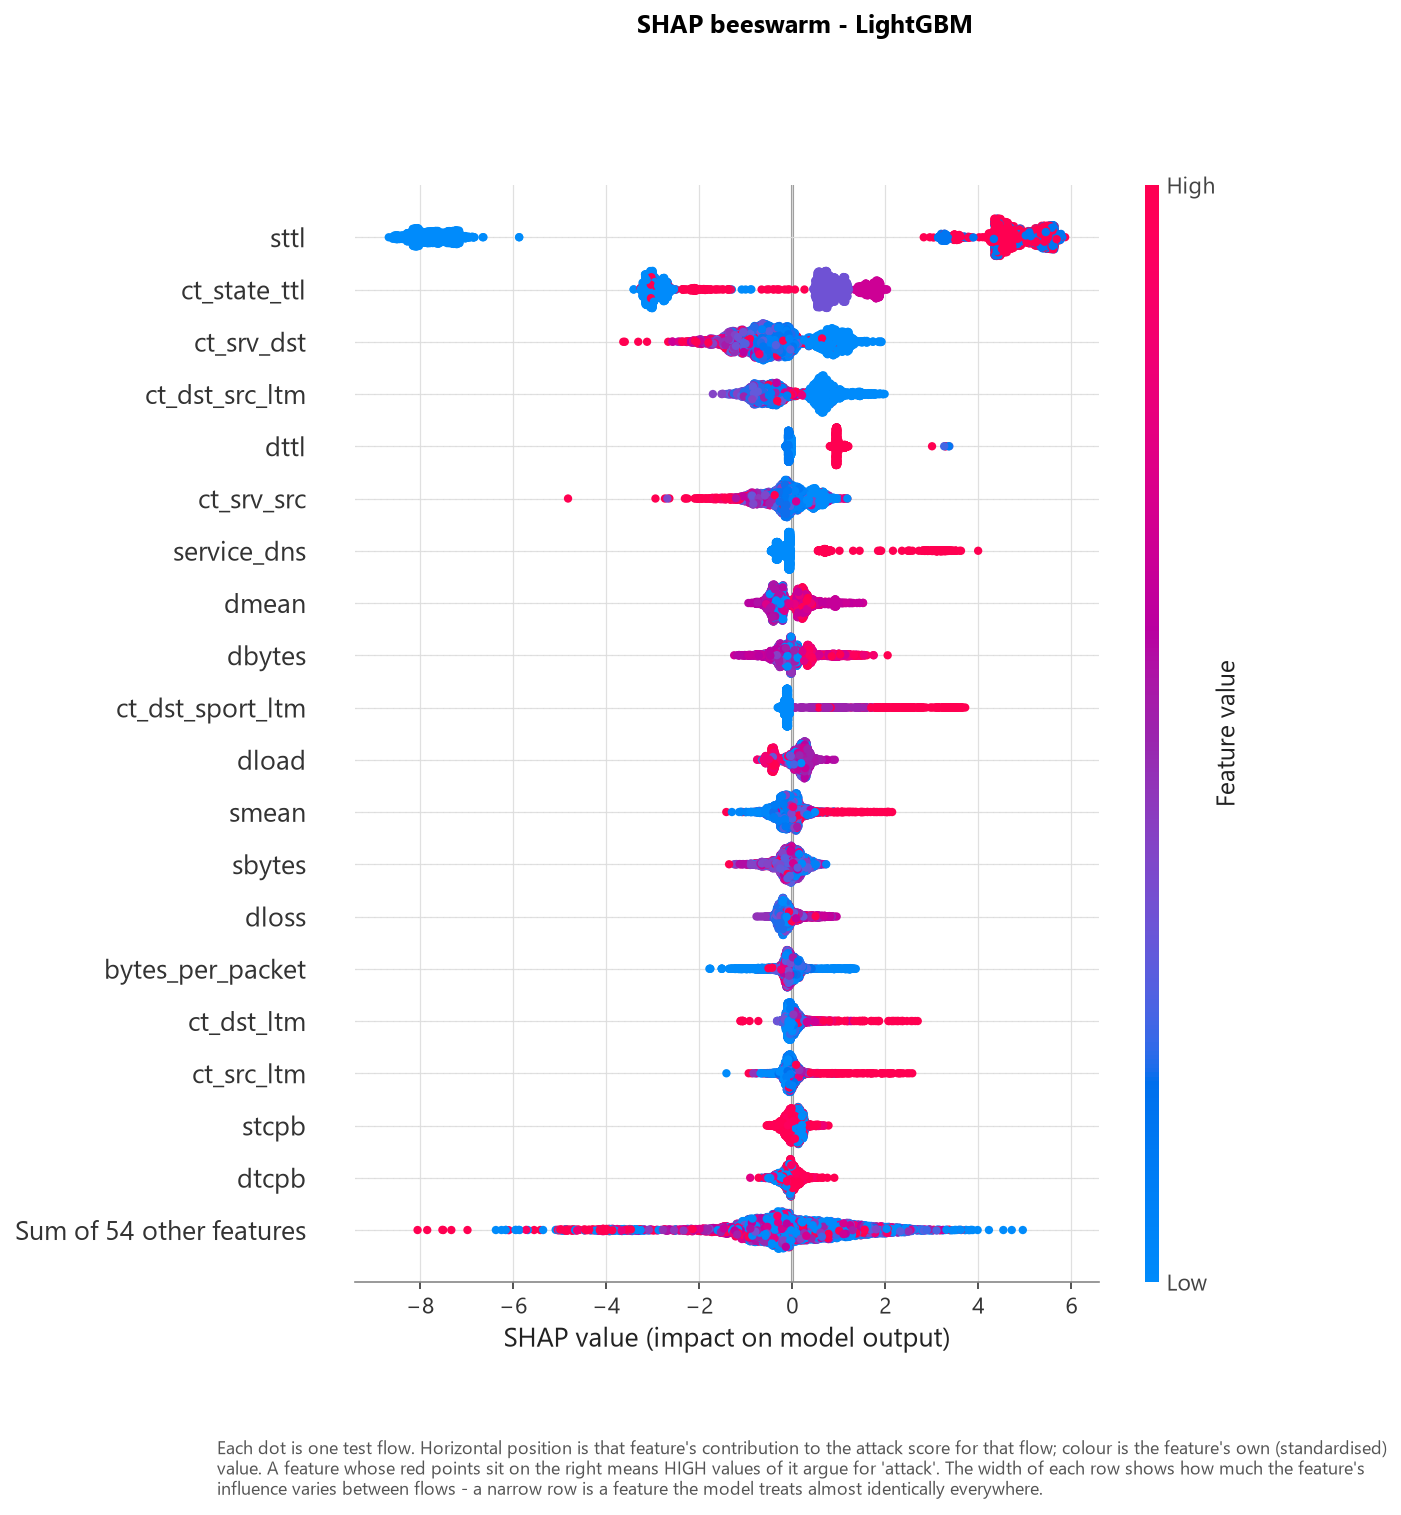

In [6]:
show("fig21_shap_beeswarm")

Each dot is one test flow. Horizontal position is that feature's contribution to
the attack score for that flow; colour is the feature's own standardised value.

A feature whose red points sit on the right means **high values of it argue for
"attack"**. The width of each row shows how much a feature's influence varies
between flows — a narrow row is a feature the model treats almost identically
everywhere.

## 3. Dependence — how a feature's value maps to its effect

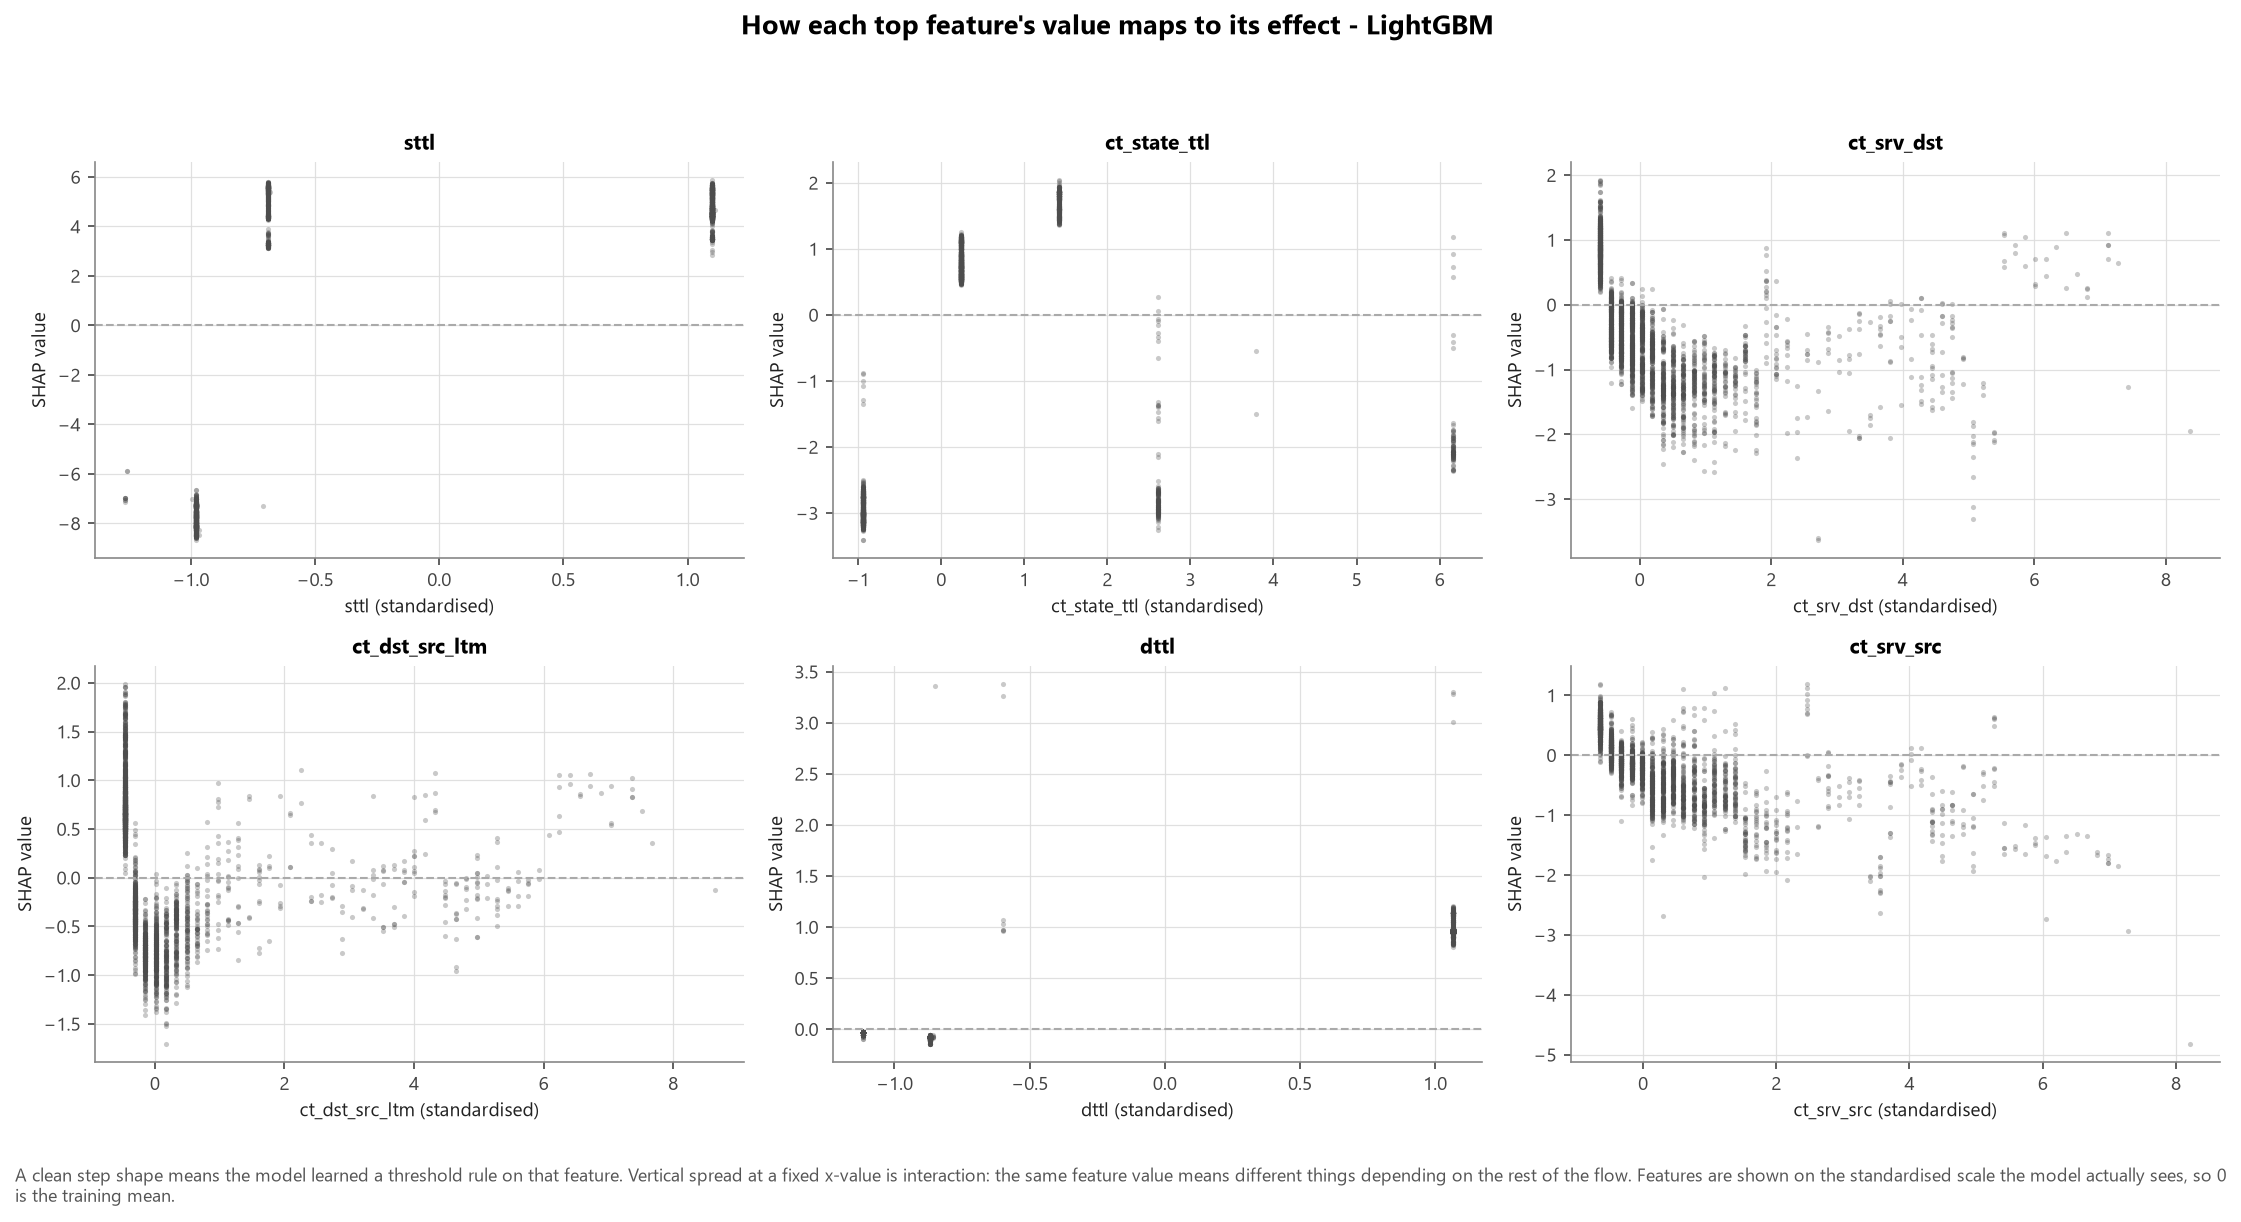

In [7]:
show("fig22_shap_dependence")

A clean step shape means the model learned a **threshold rule**. Vertical spread
at a fixed x-value is **interaction**: the same feature value means different
things depending on the rest of the flow.

## 4. The artefact diagnostic

This is the analysis that decides whether the headline performance should be read
as *attack detection* or as *testbed recognition*.

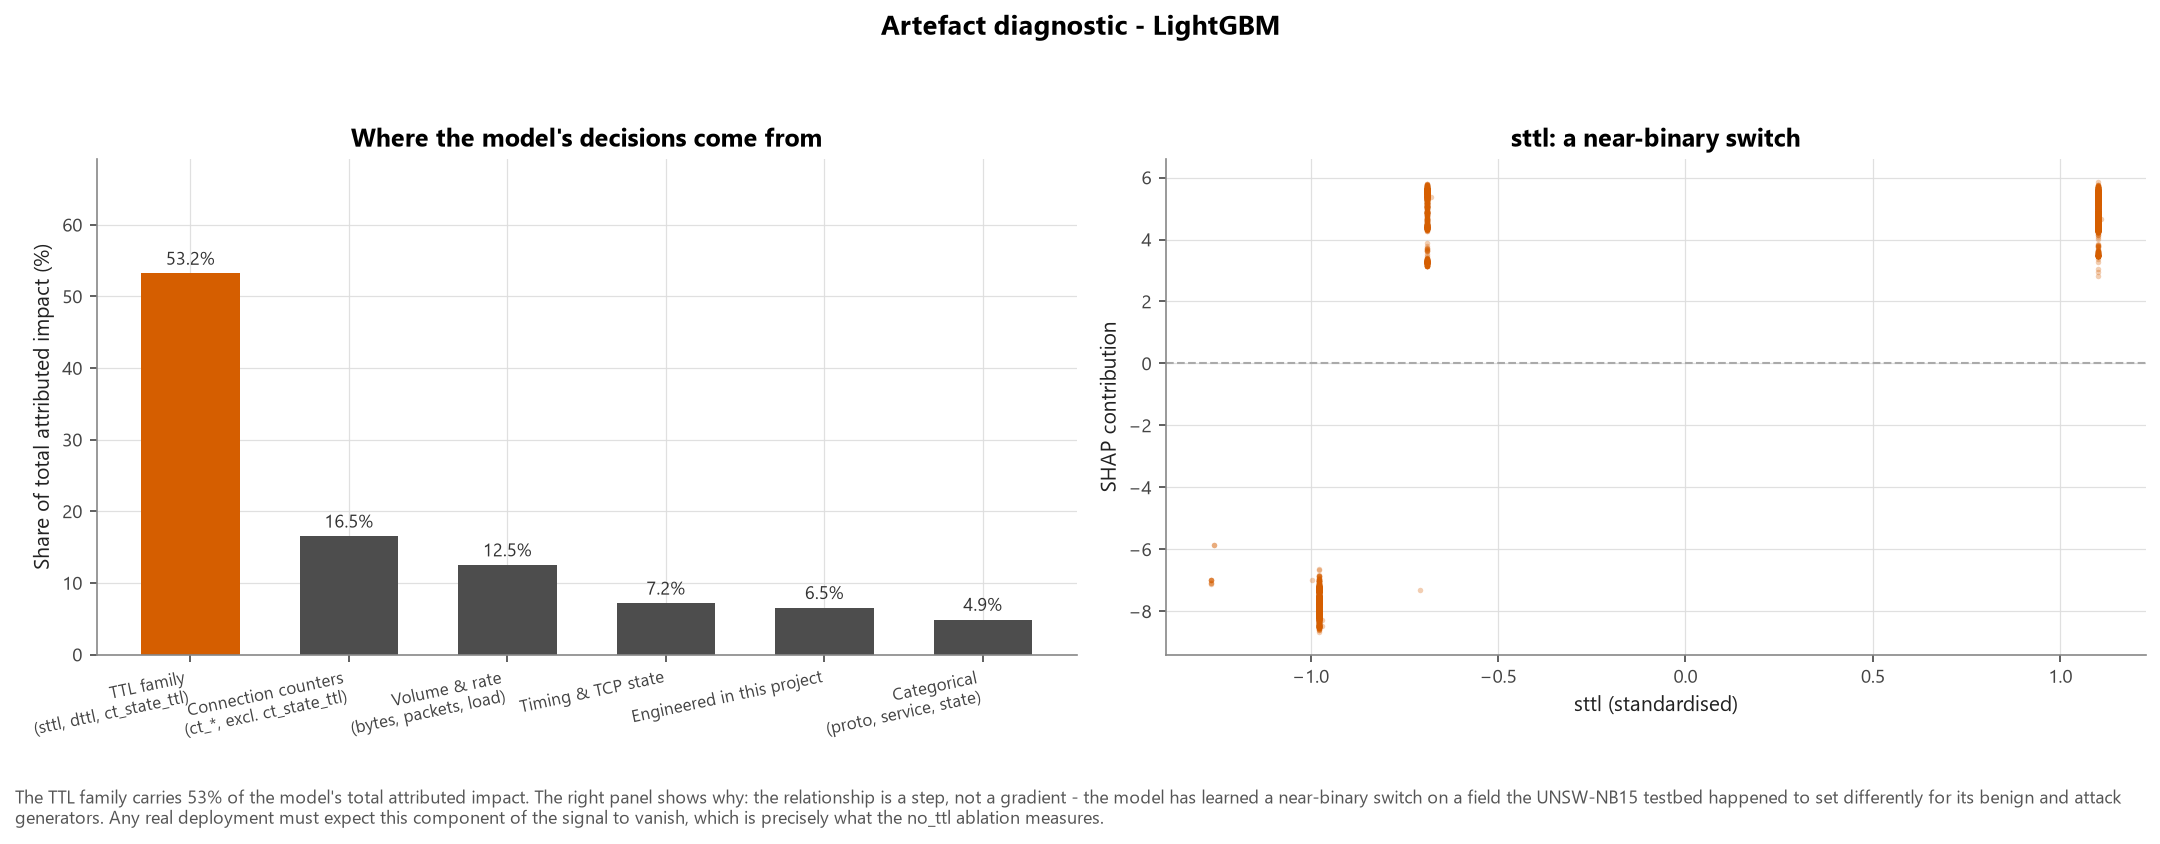

In [8]:
show("fig24_shap_artifact_check")

In [9]:
if shap_payload and "artifact_diagnostic" in shap_payload:
    diagnostic = shap_payload["artifact_diagnostic"]
    shares = pd.Series(diagnostic["impact_share_by_group"]).sort_values(ascending=False)
    shares.index = [i.replace("\n", " ") for i in shares.index]
    display(shares.to_frame("share_of_total_impact").style.format("{:.1%}"))
    print(f"\nTTL family share of total attributed impact: "
          f"{diagnostic['ttl_family_share']:.1%}")

,share_of_total_impact
"TTL family (sttl, dttl, ct_state_ttl)",53.2%
"Connection counters (ct_*, excl. ct_state_ttl)",16.5%
"Volume & rate (bytes, packets, load)",12.5%
Timing & TCP state,7.2%
Engineered in this project,6.5%
"Categorical (proto, service, state)",4.9%



TTL family share of total attributed impact: 53.2%


### Interpretation

The EDA raised a suspicion; SHAP converts it into a measured quantity **on the
fitted model**. The dependence plot shows the relationship is a *step*, not a
gradient — the model has learned a near-binary switch on a field the UNSW-NB15
testbed happened to configure differently for its benign and attack generators.

**The response is measurement, not deletion.** The features stay (they are real
fields a sensor observes), and the `no_ttl` ablation in notebook 05 shows what
performance survives without them.

## 5. Local explanations

Four cases, each chosen as the **median-scoring** member of its outcome class so
the explanation describes typical model behaviour rather than a cherry-picked
extreme.

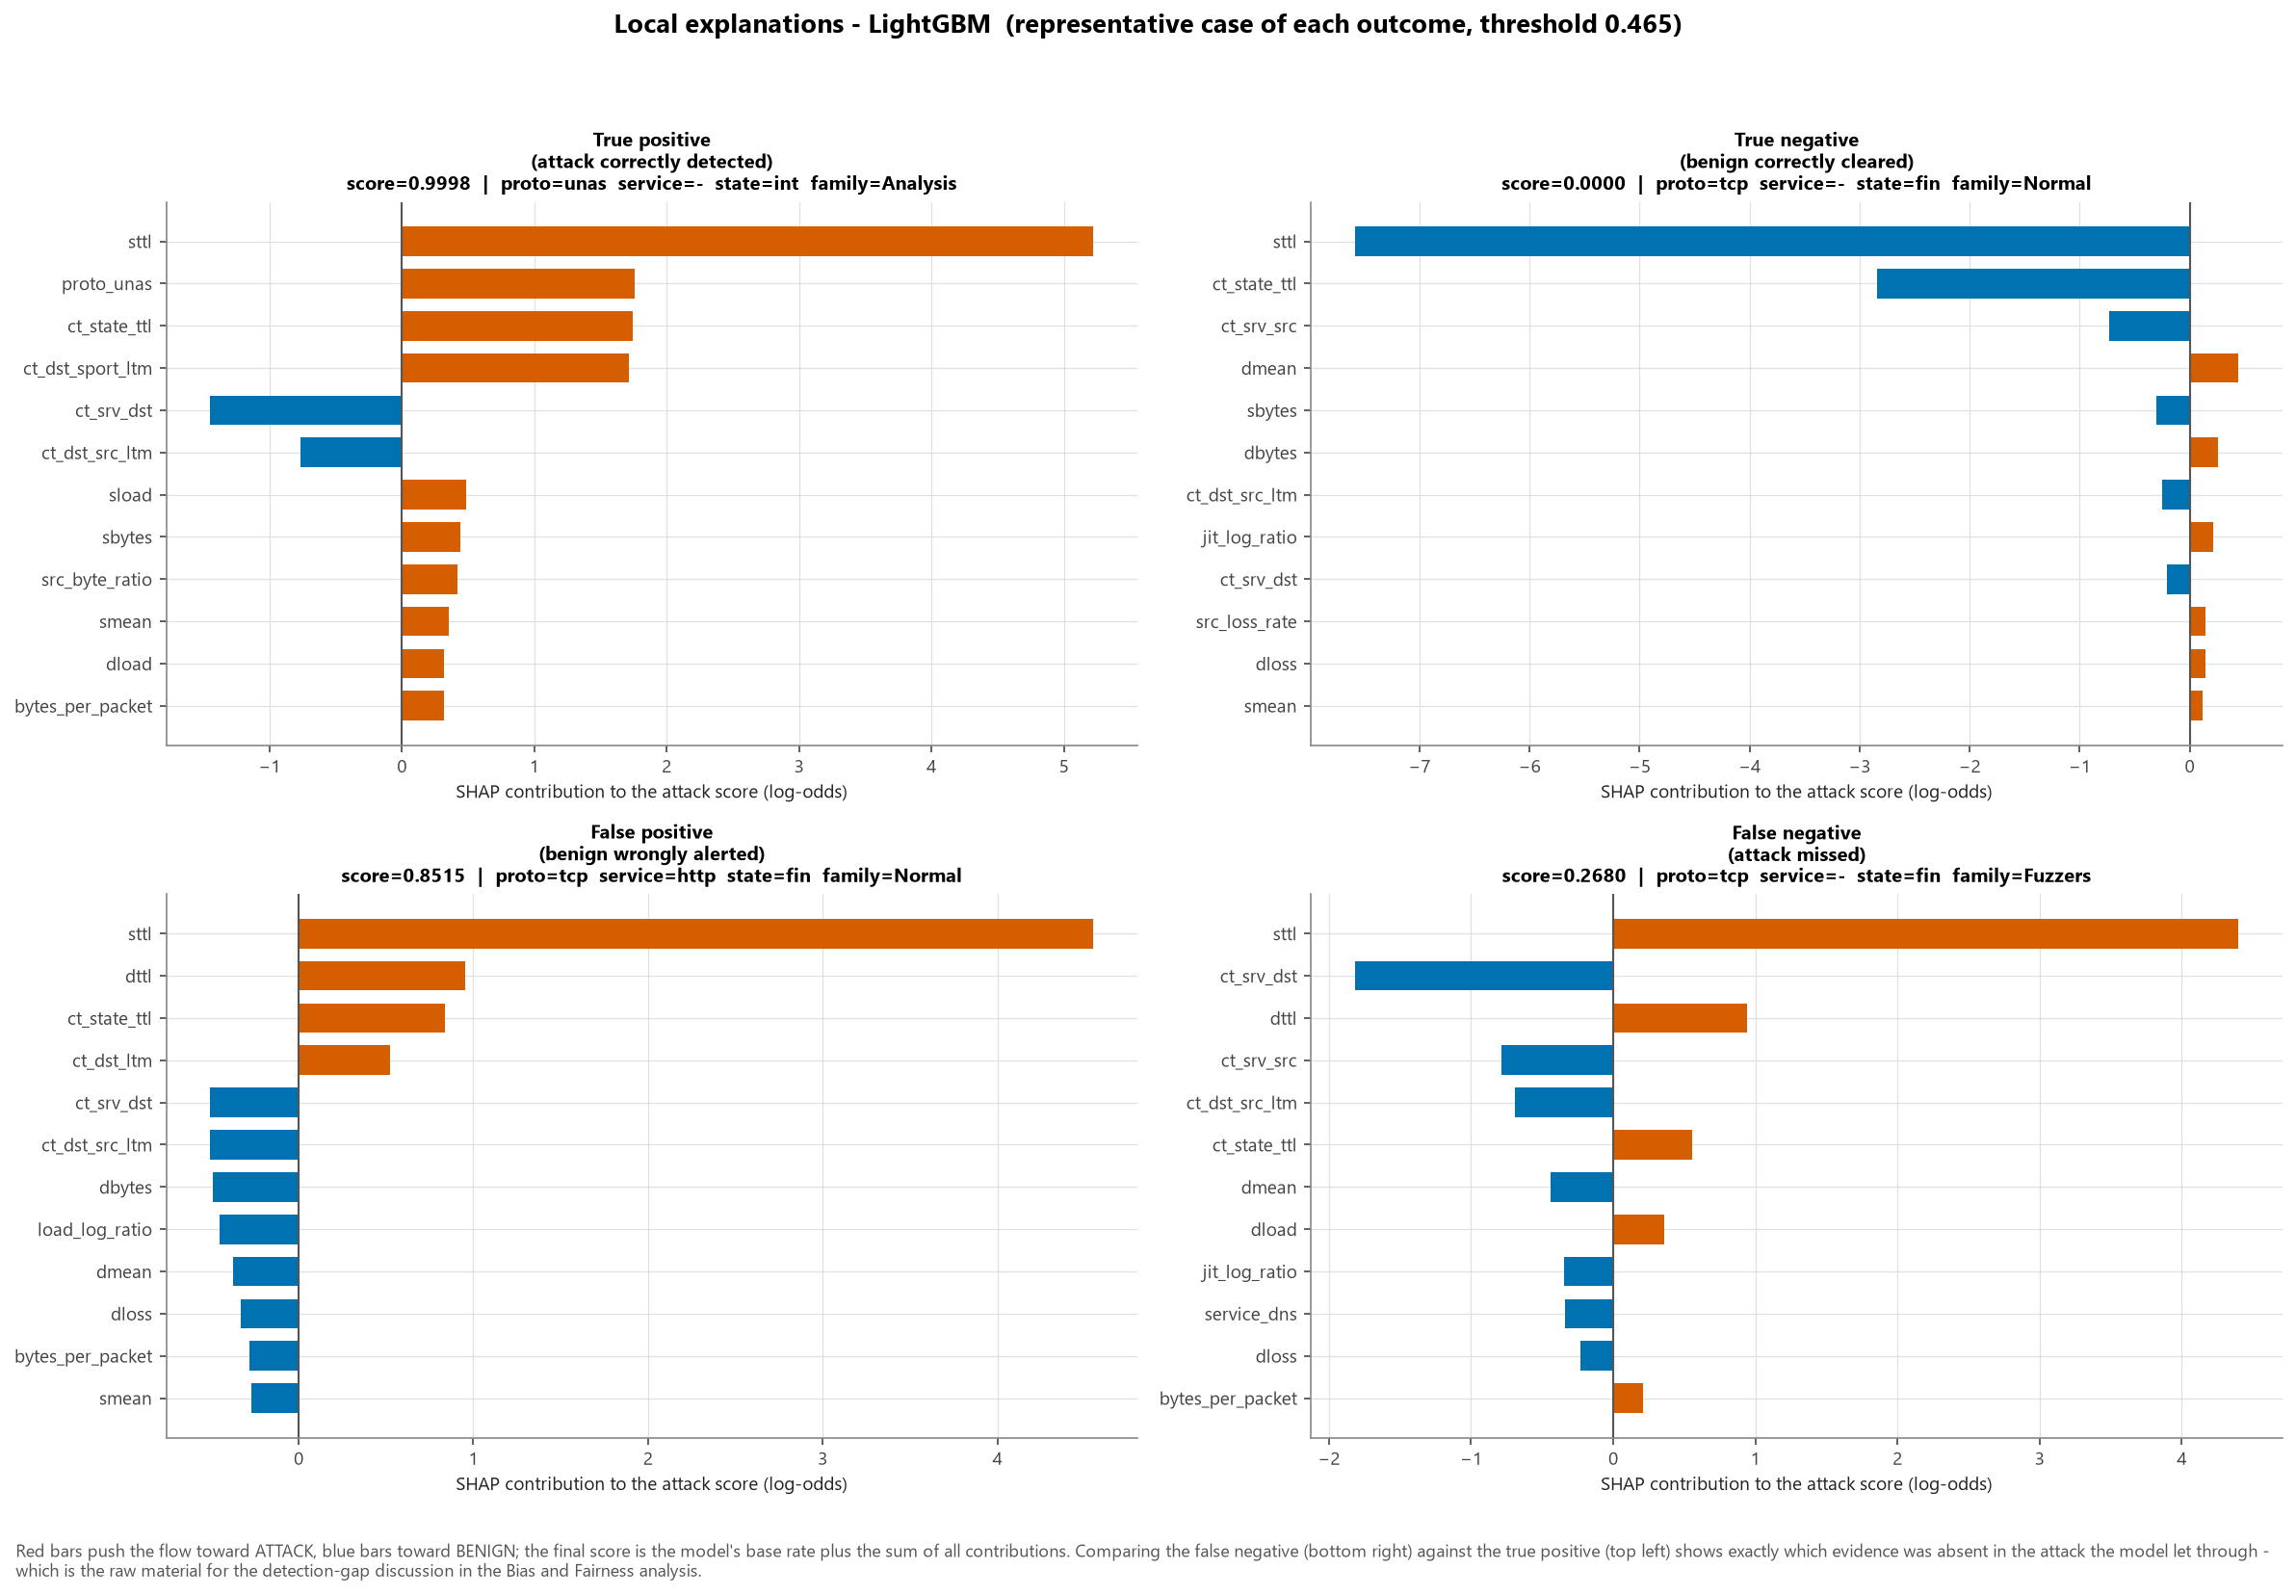

In [10]:
show("fig23_shap_local_cases")

In [11]:
if shap_payload and "local_cases" in shap_payload:
    for title, case in shap_payload["local_cases"].items():
        print(f"=== {title} ===")
        print(f"  score={case['attack_score']:.4f}  true={case['true_label']}  "
              f"pred={case['predicted']}  family={case['attack_cat']}")
        print(f"  proto={case['proto']}  service={case['service']}  state={case['state']}")
        for contribution in case["top_contributions"][:5]:
            arrow = "-> ATTACK" if contribution["shap"] > 0 else "-> BENIGN"
            print(f"      {contribution['feature']:<26} "
                  f"{contribution['shap']:+.4f}  {arrow}")
        print()

=== True positive (attack correctly detected) ===
  score=0.9998  true=1  pred=1  family=Analysis
  proto=unas  service=-  state=int
      sttl                       +5.2229  -> ATTACK
      proto_unas                 +1.7596  -> ATTACK
      ct_state_ttl               +1.7430  -> ATTACK
      ct_dst_sport_ltm           +1.7168  -> ATTACK
      ct_srv_dst                 -1.4465  -> BENIGN

=== True negative (benign correctly cleared) ===
  score=0.0000  true=0  pred=0  family=Normal
  proto=tcp  service=-  state=fin
      sttl                       -7.5831  -> BENIGN
      ct_state_ttl               -2.8387  -> BENIGN
      ct_srv_src                 -0.7356  -> BENIGN
      dmean                      +0.4414  -> ATTACK
      sbytes                     -0.3000  -> BENIGN

=== False positive (benign wrongly alerted) ===
  score=0.8515  true=0  pred=1  family=Normal
  proto=tcp  service=http  state=fin
      sttl                       +4.5491  -> ATTACK
      dttl                       

Comparing the **false negative** against the **true positive** shows exactly
which evidence was absent in the attack the model let through. That comparison is
the raw material for the detection-gap discussion below.

## 6. Operational subgroup audit

### What kind of audit this is — and what it is not

**UNSW-NB15 contains no demographic attributes and no human subjects.** It is
synthetic traffic generated on a closed testbed; the partitioned files omit every
IP address, port number and timestamp, so there is not even an indirect
identifier from which a protected characteristic could be inferred.

**Therefore no demographic fairness claim is made, and none can be made from this
dataset.** What is performed instead is an **operational performance audit**
across the strata that genuinely exist: attack family, application service,
transport protocol and connection state.

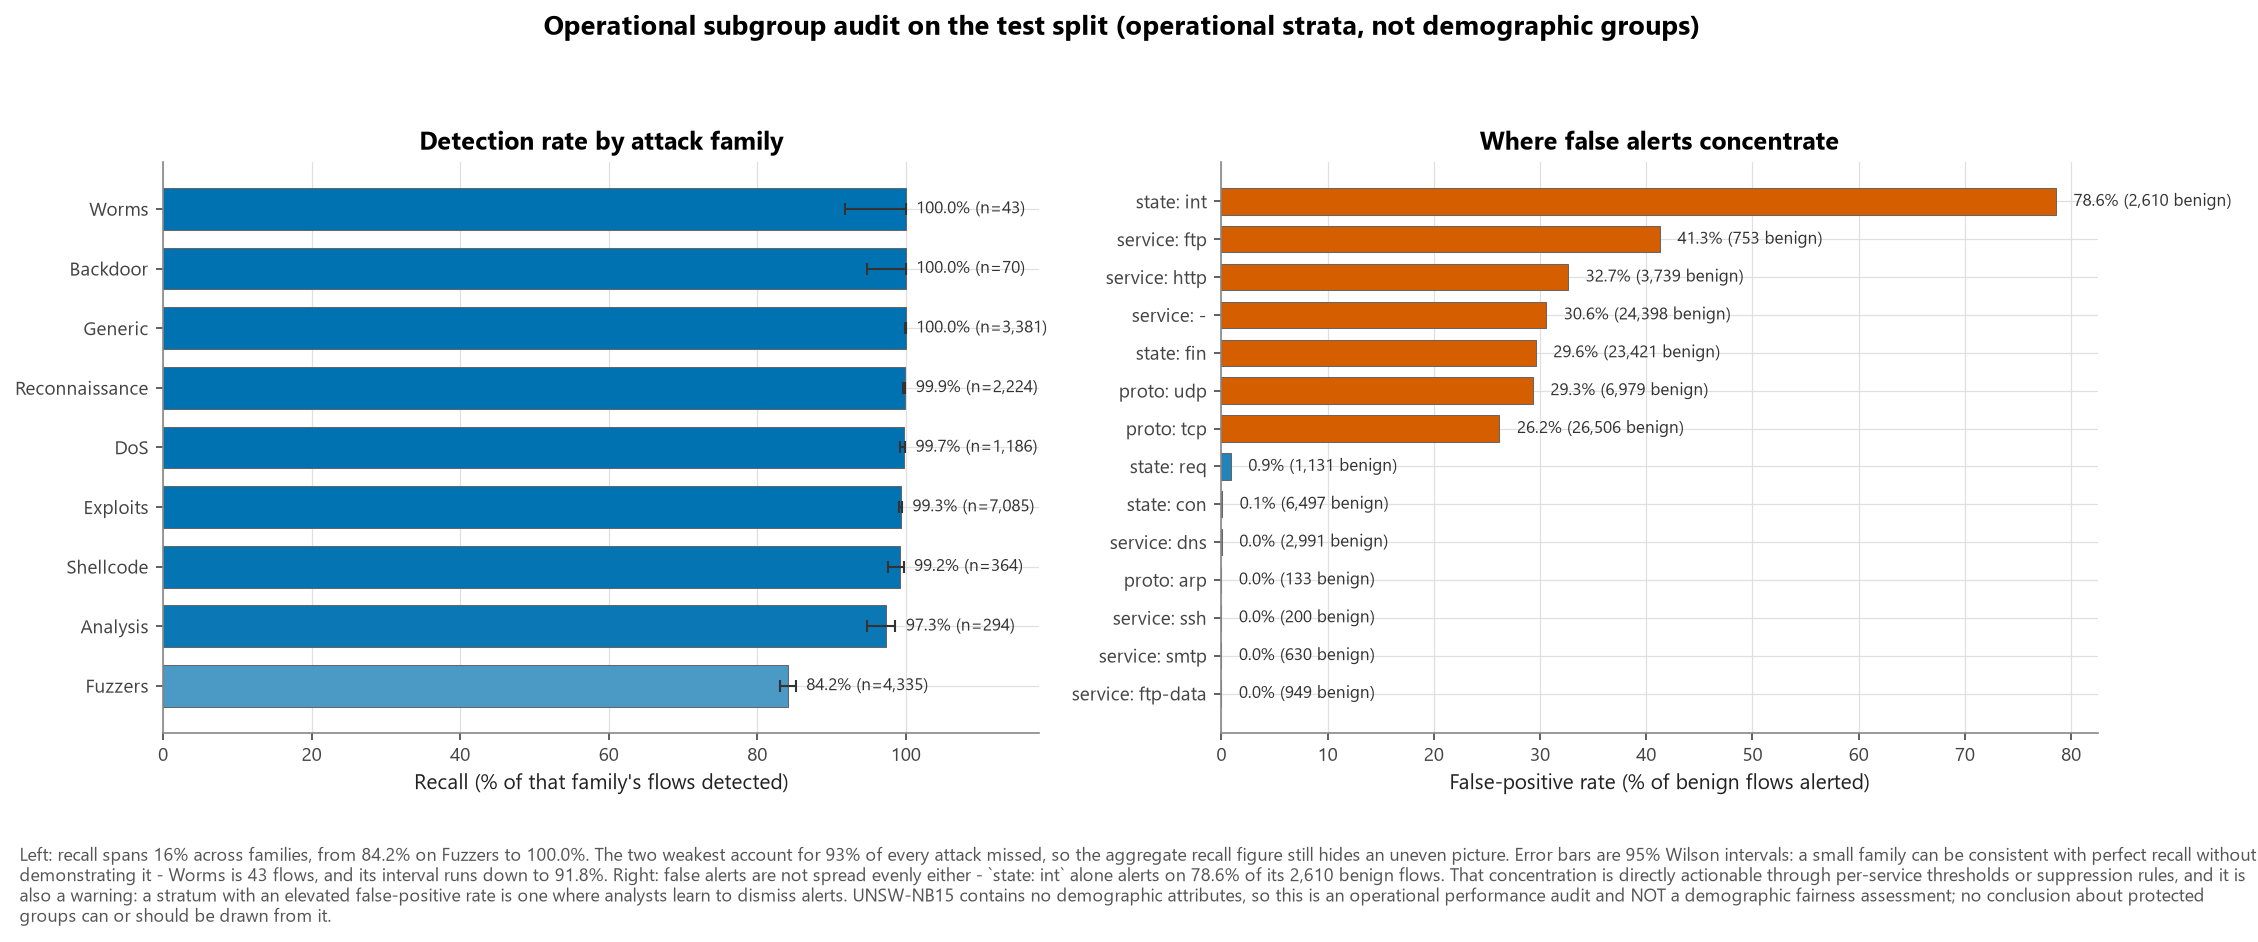

In [12]:
show("fig18_subgroup_audit")

In [13]:
audit_path = config.METRICS_DIR / "subgroup_audit_main.csv"
if audit_path.exists():
    audit = pd.read_csv(audit_path)

    families = audit[audit["group_type"] == "attack_cat"]
    families = families[families["n_attack"] > 0].sort_values("recall")
    display(Markdown("### Recall by attack family"))
    display(families[["group", "n_attack", "recall", "false_negative_rate"]]
            .set_index("group")
            .style.format({"n_attack": "{:,.0f}", "recall": "{:.4f}",
                           "false_negative_rate": "{:.4f}"}))

### Recall by attack family

,n_attack,recall,false_negative_rate
group,,,
Fuzzers,"4,335",0.8415,0.1585
Analysis,294,0.9728,0.0272
Shellcode,364,0.9918,0.0082
Exploits,"7,085",0.9934,0.0066
DoS,"1,186",0.9975,0.0025
Reconnaissance,"2,224",0.9987,0.0013
Generic,"3,381",1.0000,0.0000
Backdoor,70,1.0000,0.0000
Worms,43,1.0000,0.0000


In [14]:
if audit_path.exists():
    for group_type in ("service", "proto", "state"):
        sub = audit[(audit["group_type"] == group_type) & (audit["n_benign"] >= 30)]
        sub = sub.sort_values("false_positive_rate", ascending=False).head(8)
        if sub.empty:
            continue
        display(Markdown(f"### {group_type} — where false alerts concentrate"))
        display(sub[["group", "n", "n_benign", "recall", "precision",
                     "false_positive_rate", "f1"]].set_index("group")
                .style.format({"n": "{:,.0f}", "n_benign": "{:,.0f}",
                               "recall": "{:.4f}", "precision": "{:.4f}",
                               "false_positive_rate": "{:.3%}", "f1": "{:.4f}"}))

### service — where false alerts concentrate

,n,n_benign,recall,precision,false_positive_rate,f1
group,,,,,,
ftp,"1,291",753,0.9387,0.6189,41.301%,0.7459
http,"7,891","3,739",0.9945,0.7718,32.656%,0.8691
-,"34,024","24,398",0.9278,0.5447,30.597%,0.6864
dns,"5,848","2,991",1.0000,0.9997,0.033%,0.9998
smtp,"1,759",630,1.0000,1.0000,0.000%,1.0000
ftp-data,"1,177",949,1.0000,1.0000,0.000%,1.0000
ssh,204,200,1.0000,1.0000,0.000%,1.0000


### proto — where false alerts concentrate

,n,n_benign,recall,precision,false_positive_rate,f1
group,,,,,,
udp,"11,684","6,979",0.9492,0.6857,29.331%,0.7962
tcp,"40,467","26,506",0.9634,0.6596,26.183%,0.7831
arp,133,133,nan,nan,0.000%,0.0000


### state — where false alerts concentrate

,n,n_benign,recall,precision,false_positive_rate,f1
group,,,,,,
int,"7,486","2,610",0.9508,0.6933,78.582%,0.8019
fin,"37,314","23,421",0.9637,0.6588,29.602%,0.7826
req,"1,151","1,131",1.0000,0.6667,0.884%,0.8000
con,"6,687","6,497",0.9737,0.9737,0.077%,0.9737


### Interpretation

**Recall is not uniform.** The weakest families are the stealthy, low-volume ones
a defender would most want caught. Three distinguishable mechanisms drive this,
and they are *not* equivalent problems:

1. **Scarcity** — few training examples. Fixable with more data.
2. **Behavioural overlap with benign traffic** — a backdoor that looked like a
   port scan would be a bad backdoor. **Not fixable**, and the more serious
   finding, because it bounds what *any* flow-level detector can achieve.
3. **Duplication-distorted training counts** — families that were heavily
   duplicated contributed far fewer distinct examples than their raw counts
   suggested.

**False alerts are not spread evenly either.** A handful of services generate a
disproportionate share — which is directly actionable through per-service
thresholds, and is also a warning: a stratum with an elevated FPR is a stratum
where analysts learn to dismiss alerts, converting a precision problem into a
recall problem through human behaviour.

## 7. Error analysis

In [15]:
errors_path = config.METRICS_DIR / "error_analysis_main.json"
if errors_path.exists():
    errors = json.loads(errors_path.read_text(encoding="utf-8"))

    print("Outcome counts:")
    for outcome, count in errors["counts"].items():
        print(f"  {outcome:<18} {count:>8,}")

    if "false_negative_score_stats" in errors:
        stats = errors["false_negative_score_stats"]
        print(f"\nMissed attacks — median score {stats['median']:.4f}, "
              f"{stats['share_below_0.10']:.1%} score below 0.10")
    if "false_positive_score_stats" in errors:
        stats = errors["false_positive_score_stats"]
        print(f"False alerts   — median score {stats['median']:.4f}, "
              f"{stats['share_above_0.90']:.1%} score above 0.90")

    display(Markdown("### Median flow profile by outcome"))
    display(pd.DataFrame(errors["median_profile_by_outcome"]).T)

Outcome counts:
  true_negative        24,662
  true_positive        18,231
  false_positive        9,000
  false_negative          751

Missed attacks — median score 0.2680, 16.5% score below 0.10
False alerts   — median score 0.8514, 40.9% score above 0.90


### Median flow profile by outcome

,dur,sbytes,dbytes,spkts,dpkts,sttl,dttl,rate,smean
false_negative,0.436,680.0,268.0,10.0,6.0,254.0,252.0,42.801,63.0
false_positive,0.727,798.0,354.0,10.0,8.0,254.0,252.0,25.862,80.0
true_negative,0.080,1064.0,850.0,10.0,10.0,31.0,29.0,1048.959,73.0
true_positive,0.572,838.0,354.0,10.0,8.0,254.0,252.0,46.398,81.0


### Near-misses or confident errors?

This distinction decides what you can *do* about the errors, so it is measured
rather than assumed:

* Errors clustered just the wrong side of the threshold are **near-misses**.
  Moving the threshold trades them directly against the other error type, and a
  "review the borderline alerts" workflow genuinely catches them.
* Errors scored far from the threshold are **confident mistakes**. No threshold
  change and no triage queue recovers those.

Compare the median false-negative score printed above against the deployed
threshold. Comparing the median flow profiles then shows what a missed attack
looks like — and it looks like ordinary traffic, which is precisely the point.

## 8. Where genuine fairness risk does enter

The dataset has no protected attributes, but a **deployed** system runs on a real
network used by real people:

1. **Uneven burden across teams.** Over-flagging a service means the humans who
   use it are investigated more often. Research groups, developers and network
   engineers whose legitimate work looks statistically unusual absorb
   disproportionate scrutiny. Section 6 shows this is already true across
   services.
2. **Assistive technologies.** Screen readers and alternative input devices can
   produce atypical traffic patterns.
3. **Feedback loops.** Flagged users are monitored more closely → more of their
   activity is labelled suspicious → retraining amplifies the original skew.
4. **Automation bias.** An analyst shown a 0.94 score is measurably more likely
   to confirm it than to challenge it.

These are **deployment-time risks**, not properties of UNSW-NB15 — and a bias
audit that stopped at the dataset would miss them entirely.

---

## Summary

| Question | Answer |
|---|---|
| What makes traffic look malicious? | High source TTL, unanswered connection, no completed handshake, asymmetric direction, elevated connection counters |
| What makes it look benign? | Completed handshake with sequence exchange, balanced bidirectional volume, identified service |
| Is a proxy feature dominating? | **Yes** — the TTL family, named and quantified rather than hidden |
| Is detection uniform? | **No** — stealthy low-volume families are substantially weaker |
| Are false alerts uniform? | **No** — they concentrate in specific services |
| Can we claim demographic fairness? | **No** — and we do not. The data cannot support it |

Full analysis:
[`reports/Bias_Fairness_Analysis.md`](../reports/Bias_Fairness_Analysis.md).